# DeepAgents Integration — GOAP as Tool or Subagent

LangGOAP's planning loop can be embedded inside a larger agent architecture
in two ways:

1. **`create_goap_tool`** — wraps a `GoapGraph` as a LangChain
   `StructuredTool`.  The calling agent invokes it via the standard
   tool-calling flow.
2. **`create_goap_subagent`** — returns a `CompiledSubAgent`-compatible
   dict whose `runnable` accepts `{messages: [HumanMessage(...)]}` and
   returns `{messages: [AIMessage(...)]}` — the DeepAgents subagent
   protocol.

Both use `GoalInterpreter` under the hood to convert a natural-language
request into a `GoalSpec` before running the planner.

## Domain — Content Analysis Pipeline

Four LLM-powered actions form a sequential pipeline:

| Action | What the LLM does |
|--------|-------------------|
| `extract_topics` | Extract 3-5 key topics from a document |
| `analyze_sentiment` | Analyze sentiment and tone |
| `generate_summary` | Write an executive summary |
| `write_recommendations` | Produce actionable recommendations |

GOAP replaces the orchestration — the LLM calls inside each action are real.

## Setup

In [1]:
from dotenv import load_dotenv

load_dotenv()

from langchain_openai import ChatOpenAI

from langgoap import GoapGraph, GoalSpec, successful_action_names
from langgoap.integrations.deepagents import (
    create_goap_tool,
    create_goap_subagent,
    format_goap_result,
)
from tutorial_examples.deepagents_integration import (
    content_analysis_actions,
    content_analysis_goal,
)
from tutorial_examples.data.deepagents_instance import SAMPLE_DOCUMENT

llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
actions = content_analysis_actions(llm)
goal = content_analysis_goal()

print(f"Actions: {[a.name for a in actions]}")
print(f"Goal:    {dict(goal.conditions)}")
print(f"Document preview: {SAMPLE_DOCUMENT[:120]}...")

Actions: ['extract_topics', 'analyze_sentiment', 'generate_summary', 'write_recommendations']
Goal:    {'has_recommendations': True}
Document preview: The adoption of cloud-native architectures has accelerated dramatically over the past two years.  Organizations that pre...


## Direct GOAP Execution

Before wrapping as a tool, run the pipeline directly to see what
the actions produce.

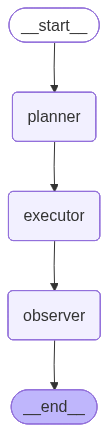

In [2]:
from IPython.display import Image, display

graph = GoapGraph(actions=actions)
display(Image(graph.compile().get_graph().draw_mermaid_png()))

In [3]:
result = graph.invoke(
    goal=goal,
    world_state={"has_document": True, "document": SAMPLE_DOCUMENT},
)

print(f"Status: {result['status']}")
print(f"Actions: {successful_action_names(result)}")
print()
ws = result["world_state"]
print("=== Topics ===")
for topic in ws.get("topics", []):
    print(f"  - {topic}")
print()
print("=== Sentiment ===")
print(ws.get("sentiment", ""))
print()
print("=== Summary ===")
print(ws.get("summary", ""))
print()
print("=== Recommendations ===")
print(ws.get("recommendations", ""))

Status: goal_achieved
Actions: ['extract_topics', 'analyze_sentiment', 'generate_summary', 'write_recommendations']

=== Topics ===
  - Adoption of cloud-native architectures and migration to microservices
  - Operational complexity and challenges in observability and configuration management
  - Security concerns related to container images and supply-chain attacks
  - Improvements in developer experience through self-service portals and GitOps workflows
  - Future trends in AI-assisted operations (AIOps) and FinOps practices

=== Sentiment ===
The overall sentiment of the document is cautiously optimistic. It highlights the rapid adoption of cloud-native architectures and the benefits they bring, such as improved scalability and developer experience, while also acknowledging the challenges and complexities that come with this transition. The tone is balanced, recognizing both the advancements in technology and the ongoing concerns, particularly around security and operational difficu

## `create_goap_tool` — Wrap as a LangChain Tool

`create_goap_tool` returns a `StructuredTool` with a single `request`
parameter.  The tool:

1. Passes the request through `GoalInterpreter` to get a `GoalSpec`.
2. Runs `GoapGraph.invoke_nl` with the interpreted goal.
3. Returns a formatted string via `format_goap_result`.

Any agent that supports LangChain tools can call this.

In [4]:
tool = create_goap_tool(
    actions,
    llm=llm,
    name="content_analyzer",
    description="Analyze a document: extract topics, sentiment, summary, and recommendations.",
    world_state={"has_document": True, "document": SAMPLE_DOCUMENT},
)

print(f"Tool name:        {tool.name}")
print(f"Tool description: {tool.description}")
print(f"Tool type:        {type(tool).__name__}")

Tool name:        content_analyzer
Tool description: Analyze a document: extract topics, sentiment, summary, and recommendations.
Tool type:        StructuredTool


In [5]:
tool_result = tool.invoke({"request": "Analyze the document and provide recommendations"})

print(tool_result)

GOAP Result: goal_achieved

Executed actions:
  - ActionResult(action_name='extract_topics', success=True, state_before={'has_document': True, 'document': 'The adoption of cloud-native architectures has accelerated dramatically over the past two years.  Organizations that previously relied on monolithic deployments are migrating to microservices orchestrated by Kubernetes, benefiting from improved scalability and fault isolation.  However, the transition introduces operational complexity: observability stacks must cover distributed traces, service meshes add latency overhead, and configuration drift across hundreds of services becomes a real risk.\n\nSecurity teams report mixed feelings.  Container image scanning and runtime policies have matured, yet supply-chain attacks targeting base images and third-party dependencies remain a top concern.  Zero-trust networking principles are gaining traction, but retrofitting them into brownfield environments is expensive and disruptive.\n\nDevel

## `format_goap_result` — Pretty-Print Results

`format_goap_result` converts a raw `GoapState` dict into a
human-readable report showing status, executed actions, and
final world state.

In [6]:
# Format the direct execution result from earlier
formatted = format_goap_result(dict(result))
print(formatted)

GOAP Result: goal_achieved

Executed actions:
  - ActionResult(action_name='extract_topics', success=True, state_before={'has_document': True, 'document': 'The adoption of cloud-native architectures has accelerated dramatically over the past two years.  Organizations that previously relied on monolithic deployments are migrating to microservices orchestrated by Kubernetes, benefiting from improved scalability and fault isolation.  However, the transition introduces operational complexity: observability stacks must cover distributed traces, service meshes add latency overhead, and configuration drift across hundreds of services becomes a real risk.\n\nSecurity teams report mixed feelings.  Container image scanning and runtime policies have matured, yet supply-chain attacks targeting base images and third-party dependencies remain a top concern.  Zero-trust networking principles are gaining traction, but retrofitting them into brownfield environments is expensive and disruptive.\n\nDevel

## `create_goap_subagent` — Messages-Protocol Subagent

`create_goap_subagent` returns a dict with `name`, `description`, and
`runnable` keys — matching the `CompiledSubAgent` protocol.  The
`runnable` is a compiled `StateGraph` that:

1. Extracts the task from the last `HumanMessage`.
2. Runs `GoapGraph.invoke_nl`.
3. Returns an `AIMessage` with the formatted result.

This allows GOAP to be embedded in any multi-agent system that
communicates via message passing.

In [7]:
from langchain_core.messages import HumanMessage

subagent = create_goap_subagent(
    actions,
    llm=llm,
    name="content_analyzer",
    description="Analyzes documents using GOAP planning.",
    world_state={"has_document": True, "document": SAMPLE_DOCUMENT},
)

print(f"Subagent name:        {subagent['name']}")
print(f"Subagent description: {subagent['description']}")
print(f"Runnable type:        {type(subagent['runnable']).__name__}")

Subagent name:        content_analyzer
Subagent description: Analyzes documents using GOAP planning.
Runnable type:        CompiledStateGraph


In [8]:
subagent_result = subagent["runnable"].invoke(
    {"messages": [HumanMessage(content="Analyze the document and provide recommendations")]}
)

final_message = subagent_result["messages"][-1]
print(f"Message type: {type(final_message).__name__}")
print()
print(final_message.content)

Message type: AIMessage

GOAP Result: goal_achieved

Executed actions:
  - ActionResult(action_name='extract_topics', success=True, state_before={'has_document': True, 'document': 'The adoption of cloud-native architectures has accelerated dramatically over the past two years.  Organizations that previously relied on monolithic deployments are migrating to microservices orchestrated by Kubernetes, benefiting from improved scalability and fault isolation.  However, the transition introduces operational complexity: observability stacks must cover distributed traces, service meshes add latency overhead, and configuration drift across hundreds of services becomes a real risk.\n\nSecurity teams report mixed feelings.  Container image scanning and runtime policies have matured, yet supply-chain attacks targeting base images and third-party dependencies remain a top concern.  Zero-trust networking principles are gaining traction, but retrofitting them into brownfield environments is expensive

## Tool vs. Subagent — When to Use Which

| | `create_goap_tool` | `create_goap_subagent` |
|---|---|---|
| **Protocol** | `BaseTool` — string in, string out | Messages — `HumanMessage` in, `AIMessage` out |
| **Use case** | Tool-calling agents (ReAct, OpenAI function calling) | Multi-agent systems (supervisor, swarm) |
| **Return type** | `str` | `dict["messages"]` |
| **Async** | `.ainvoke()` | `.ainvoke()` |

Both share the same underlying `GoapGraph` and `GoalInterpreter`
machinery — the difference is only the input/output protocol.

## Summary

- **`create_goap_tool`** wraps GOAP as a `StructuredTool` — any
  tool-calling agent can invoke it with a natural-language request.
- **`create_goap_subagent`** wraps GOAP as a messages-protocol
  subagent — compatible with DeepAgents and similar multi-agent
  frameworks.
- **`format_goap_result`** renders execution results as a
  human-readable report.
- All four content-analysis actions use **real LLM calls** — GOAP
  handles the orchestration, not the intelligence.

Every scenario here is verified by
[`tests/integration/test_deepagents_integration.py`](../../tests/integration/test_deepagents_integration.py).